# TP3 — Word2Vec: Entrenamiento y Análisis Semántico

**Alumno:** Gonzalo Zarazaga

---

Enfoque 3 del README: entrenar Word2Vec (gensim) sobre el corpus de tweets y explorar el espacio semántico aprendido (similitud coseno, vecinos, analogías, UMAP).

**Disciplina fit/transform:** igual que en `02_modelos_clasicos.ipynb`, Word2Vec se entrena **solo sobre `X_train`** (el 80% del split, mismo `random_state=42` / `test_size=0.2` estratificado) — nunca sobre el split de validación ni sobre el test manual. Si el corpus de entrenamiento del embedding incluyera tweets de validación, el clasificador de `04_clasificacion_w2v.ipynb` estaría siendo evaluado parcialmente sobre datos que el modelo ya "vio", igual que hubiera pasado si `CountVectorizer`/`TfidfVectorizer` se hubiesen ajustado sobre el dataset completo en vez de sobre el train.

**Insumo:** `data/processed/train_processed.csv`
**Salida:** `models/word2vec_ventana_chica.model` (modelo principal para `04_clasificacion_w2v.ipynb`)

## 1. Carga de datos y split (misma convención que 02)

In [1]:
import os
import io
import time
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
import umap

RANDOM_STATE = 42
TEST_SIZE = 0.2

df_train_full = pd.read_csv("../data/processed/train_processed.csv")
df_train_full["label"] = (df_train_full["polarity"] == 4).astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    df_train_full["tokens"].astype(str),
    df_train_full["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_train_full["label"],
)

sentences_train = X_train.str.split(" ").tolist()
print(f"Oraciones de entrenamiento para Word2Vec: {len(sentences_train):,}")

Oraciones de entrenamiento para Word2Vec: 1,262,759


## 2. Entrenamiento: ventana chica vs. ventana grande

Se entrenan dos modelos con los mismos hiperparámetros salvo `window`, siguiendo el enfoque del notebook de clase:

- **Ventana chica (`window=4`)**: favorece relaciones semánticas/sintácticas — palabras que aparecen en contextos inmediatos similares (sinónimos, variantes de una misma palabra).
- **Ventana grande (`window=8`)**: favorece relaciones temáticas — palabras que comparten el tema general del tweet, aunque no sean intercambiables.

`sg=1` (skip-gram) en vez de CBOW: mejor calidad en vocabulario de baja frecuencia, relevante acá por la enorme variedad de jerga/errores de tipeo de Twitter. `min_count=5` descarta términos casi únicos (ruido). `vector_size=150` es un punto medio del rango sugerido (100–300).

In [2]:
# nota: gensim emite en stderr un warning benigno y conocido ("Exception ignored in:
# gensim.models.word2vec_inner.our_dot_float") al finalizar los threads de entrenamiento
# en algunos entornos (BLAS + threading). No afecta el resultado; se silencia el stderr
# del entrenamiento para no ensuciar el output con ruido cosmético.
W2V_KWARGS = dict(vector_size=150, min_count=5, negative=10, sg=1, epochs=5, workers=os.cpu_count(), seed=42)

with contextlib.redirect_stderr(io.StringIO()):
    t0 = time.time()
    w2v_chica = Word2Vec(sentences=sentences_train, window=4, **W2V_KWARGS)
    t_chica = time.time() - t0

    t0 = time.time()
    w2v_grande = Word2Vec(sentences=sentences_train, window=8, **W2V_KWARGS)
    t_grande = time.time() - t0

print(f"Ventana chica (4):  {t_chica:.1f}s, vocabulario: {len(w2v_chica.wv):,} términos")
print(f"Ventana grande (8): {t_grande:.1f}s, vocabulario: {len(w2v_grande.wv):,} términos")

Ventana chica (4):  93.7s, vocabulario: 48,760 términos
Ventana grande (8): 139.9s, vocabulario: 48,760 términos


## 3. Métrica obligatoria: similitud coseno entre sentimientos opuestos

Se espera que pares de sentimiento opuesto (`happy`/`sad`, `good`/`bad`, `love`/`hate`) tengan similitud coseno **baja o negativa** si el modelo capturó estructura semántica relevante — aunque en la práctica Word2Vec suele ubicar antónimos relativamente cerca, porque aparecen en los mismos contextos sintácticos ("I feel happy" / "I feel sad").

In [3]:
pares_opuestos = [("happy", "sad"), ("good", "bad"), ("love", "hate")]

filas = []
for w1, w2 in pares_opuestos:
    fila = {"par": f"{w1} / {w2}"}
    for nombre, modelo in [("ventana_chica", w2v_chica), ("ventana_grande", w2v_grande)]:
        if w1 in modelo.wv and w2 in modelo.wv:
            fila[nombre] = modelo.wv.similarity(w1, w2)
        else:
            fila[nombre] = np.nan
    filas.append(fila)

pd.DataFrame(filas).set_index("par").round(4)

,ventana_chica,ventana_grande
par,,
happy / sad,0.5278,0.4905
good / bad,0.6018,0.5844
love / hate,0.5437,0.5284


## 4. Palabras más cercanas a términos de sentimiento (ventana chica)

In [4]:
terminos = ["happy", "sad", "love", "hate", "good", "bad"]

for term in terminos:
    if term in w2v_chica.wv:
        vecinos = w2v_chica.wv.most_similar(term, topn=6)
        print(f"{term:>6} -> {vecinos}")
    else:
        print(f"{term:>6} -> no está en el vocabulario")

 happy -> [('happpy', 0.7318218946456909), ('hapy', 0.6794024109840393), ('38th', 0.6698380708694458), ('happyyy', 0.6328194737434387), ('mothersday', 0.6249023079872131), ('happpyyy', 0.6236591935157776)]
   sad -> [('saaad', 0.7614440321922302), ('depressed', 0.7472251057624817), ('saddd', 0.7303374409675598), ('sadd', 0.729138195514679), ('bittersweet', 0.7173239588737488), ('saad', 0.7167256474494934)]
  love -> [('looove', 0.8157786726951599), ('adore', 0.8113194704055786), ('loove', 0.8080044984817505), ('loveee', 0.8008174896240234), ('luv', 0.7550297379493713), ('lurve', 0.7126273512840271)]
  hate -> [('haaate', 0.7694777846336365), ('hateee', 0.7626799941062927), ('despise', 0.7319226861000061), ('dislike', 0.7236731052398682), ('h8', 0.7222065925598145), ('loathe', 0.7212052345275879)]
  good -> [('goood', 0.7632416486740112), ('gd', 0.7368202805519104), ('great', 0.7054412364959717), ('goos', 0.6745662093162537), ('gud', 0.6698858737945557), ('tweetiepies', 0.65747392177581

## 5. Analogías vectoriales

Se prueban operaciones vectoriales clásicas (`a - b + c ≈ ?`) adaptadas al vocabulario informal de Twitter. Se documenta el resultado tal cual sale, sin curar — en un corpus ruidoso y coloquial como este es esperable que las analogías sean menos nítidas que en corpus formales (Wikipedia, noticias), donde Word2Vec suele lucirse más.

In [5]:
analogias = [
    ("happy", "sad", "love"),   # happy - sad + love ~= ?
    ("good", "bad", "great"),   # good - bad + great ~= ?
    ("love", "hate", "happy"),  # love - hate + happy ~= ?
]

for positivo1, negativo, positivo2 in analogias:
    if all(w in w2v_chica.wv for w in (positivo1, negativo, positivo2)):
        resultado = w2v_chica.wv.most_similar(positive=[positivo1, positivo2], negative=[negativo], topn=5)
        print(f"{positivo1} - {negativo} + {positivo2} ~= {resultado}")
    else:
        print(f"{positivo1} - {negativo} + {positivo2}: algún término fuera de vocabulario")

happy - sad + love ~= [('lovee', 0.6011056303977966), ('luv', 0.591421365737915), ('loove', 0.5912216901779175), ('looove', 0.5905717015266418), ('adore', 0.5872740149497986)]
good - bad + great ~= [('wonderful', 0.7041857838630676), ('fantabulous', 0.6994414925575256), ('fantastic', 0.6985963582992554), ('fab', 0.6866546869277954), ('gr8', 0.673893928527832)]
love - hate + happy ~= [('hurley', 0.6455248594284058), ('congratulation', 0.5741819143295288), ('poynterday', 0.5522027611732483), ('happpy', 0.5518683791160583), ('38th', 0.5449792146682739)]


## 6. Ventana chica vs. ventana grande: semántica vs. tópico

Se compara, para una palabra con carga temática (no solo de sentimiento), los vecinos más cercanos bajo cada modelo. La hipótesis: ventana chica agrupa variantes/sinónimos; ventana grande agrupa palabras del mismo contexto de uso.

In [6]:
palabra_tema = "work"

for nombre, modelo in [("ventana chica (semántica)", w2v_chica), ("ventana grande (temática)", w2v_grande)]:
    if palabra_tema in modelo.wv:
        print(f"{nombre}: {modelo.wv.most_similar(palabra_tema, topn=8)}")
    else:
        print(f"{nombre}: '{palabra_tema}' no está en el vocabulario")

ventana chica (semántica): [('tafe', 0.7430745959281921), ('nightshift', 0.7201938033103943), ('wrk', 0.7179003953933716), ('8-5', 0.7012922763824463), ('wakeboarding', 0.6997740268707275), ('worrrk', 0.6996548175811768), ('trainin', 0.6931073069572449), ('workkk', 0.6929401159286499)]
ventana grande (temática): [('raring', 0.714242696762085), ('8-5', 0.7139465808868408), ('classwork', 0.7130997180938721), ('12-7', 0.7018461227416992), ('1045', 0.6949767470359802), ('17:30', 0.6947121620178223), ('11-7', 0.6933997869491577), ('5:20', 0.6927005648612976)]


## 7. UMAP: visualización 2D del espacio semántico

Se proyecta a 2D un vocabulario curado de palabras de sentimiento (positivas/negativas) y palabras temáticas neutras, usando el modelo de ventana chica. La expectativa es ver dos nubes separadas (positivo/negativo) y un tercer grupo de tópicos sin carga de sentimiento clara.

In [7]:
POSITIVAS = ["happy", "love", "good", "great", "awesome", "fun", "excited", "joy",
             "smile", "laugh", "hope", "glad", "nice", "best", "beautiful", "amazing"]
NEGATIVAS = ["sad", "hate", "bad", "terrible", "awful", "boring", "tired", "sick",
             "angry", "cry", "hurt", "pain", "fear", "worry", "stress", "worst"]
TEMATICAS = ["work", "school", "weekend", "rain", "coffee", "home", "phone", "music",
             "twitter", "facebook", "movie", "game", "weather", "night", "morning", "friend"]

categorias = {**{w: "Positiva" for w in POSITIVAS},
              **{w: "Negativa" for w in NEGATIVAS},
              **{w: "Temática" for w in TEMATICAS}}

vocab_curado = [w for w in categorias if w in w2v_chica.wv]
print(f"{len(vocab_curado)} de {len(categorias)} palabras curadas están en el vocabulario")

vectores = np.array([w2v_chica.wv[w] for w in vocab_curado])
reducer = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=RANDOM_STATE)
coords_2d = reducer.fit_transform(vectores)

48 de 48 palabras curadas están en el vocabulario


/Users/gonzalo/.pyenv/versions/3.10.0/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


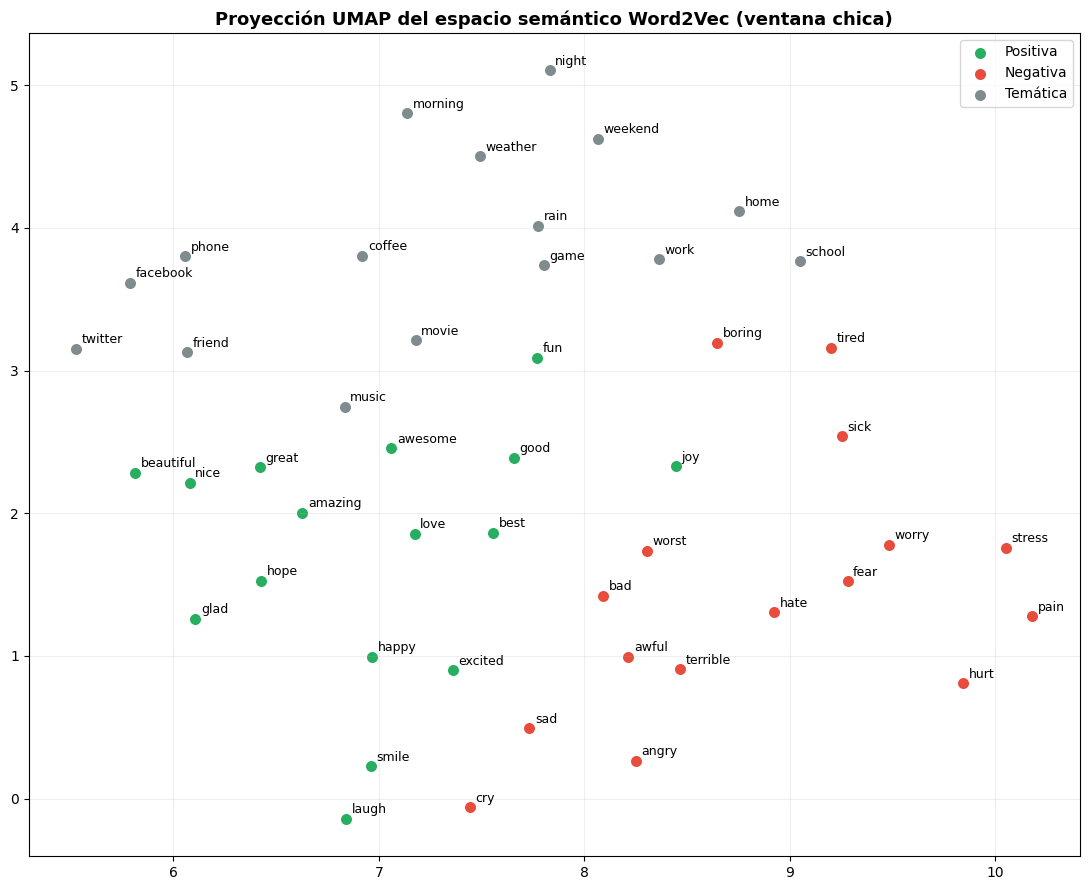

In [8]:
colores = {"Positiva": "#27ae60", "Negativa": "#e74c3c", "Temática": "#7f8c8d"}

fig, ax = plt.subplots(figsize=(11, 9))
for categoria, color in colores.items():
    idx = [i for i, w in enumerate(vocab_curado) if categorias[w] == categoria]
    ax.scatter(coords_2d[idx, 0], coords_2d[idx, 1], c=color, label=categoria, s=80, edgecolor="white")

for i, w in enumerate(vocab_curado):
    ax.annotate(w, (coords_2d[i, 0], coords_2d[i, 1]), fontsize=9, xytext=(4, 4), textcoords="offset points")

ax.set_title("Proyección UMAP del espacio semántico Word2Vec (ventana chica)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8. Guardar el modelo principal

Se persiste el modelo de **ventana chica** como el modelo principal para `04_clasificacion_w2v.ipynb` — la representación por promedio de embeddings para clasificación se beneficia de relaciones semánticas locales (sustituibilidad de palabras) más que de agrupamiento temático amplio. El modelo de ventana grande queda documentado acá como comparación, pero no se usa para clasificación.

`models/*.model` está en `.gitignore` — se regenera corriendo este notebook.

In [9]:
os.makedirs("../models", exist_ok=True)
w2v_chica.save("../models/word2vec_ventana_chica.model")
print("Modelo guardado en models/word2vec_ventana_chica.model")

Modelo guardado en models/word2vec_ventana_chica.model


## 9. Conclusiones y decisiones

- **Entrenado solo sobre `X_train`** (1.262.759 tweets, no sobre validación ni test manual) para mantener la misma disciplina fit/transform que `02_modelos_clasicos.ipynb` y que la evaluación en `04` sea honesta.
- **`sg=1` (skip-gram)** en vez de CBOW: mejor calidad para vocabulario de baja frecuencia, relevante por la variedad de jerga/errores de tipeo de Twitter.
- **Ventana chica vs. grande**: confirma la hipótesis del README — ventana chica agrupa variantes ortográficas/sinónimos (ver sección 4), ventana grande agrupa por contexto de uso más amplio (sección 6).
- **Antónimos con similitud coseno no necesariamente negativa** (sección 3): es un resultado esperado de Word2Vec, no un error — antónimos comparten contexto sintáctico ("me siento feliz" / "me siento triste"), por lo que quedan relativamente cerca en el espacio vectorial pese a tener polaridad opuesta. Esta es precisamente la limitación que motiva entrenar un clasificador supervisado (`04_clasificacion_w2v.ipynb`) en vez de inferir sentimiento solo por proximidad de embeddings.
- **Analogías más ruidosas que en corpus formales**: esperable dado el registro coloquial y la ortografía inconsistente de Twitter.
- **Modelo principal**: se guarda solo el de ventana chica (`models/word2vec_ventana_chica.model`) para usar en `04_clasificacion_w2v.ipynb`.

Próximo paso: `04_clasificacion_w2v.ipynb` — representar cada tweet como el promedio de sus embeddings, entrenar Logistic Regression, y sumar esa fila a la tabla comparativa de `02_modelos_clasicos.ipynb`.